# Import package

In [2]:
import warnings
import importlib
import os
import sys
import scanpy as sc
import pandas as pd
import anndata as ad
import numpy as np
code_dir = os.path.abspath('/home/wuyd/SpaPath/code/')
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)
import network_v1
import tools_v1
import model_v1
importlib.reload(network_v1)
importlib.reload(tools_v1)
importlib.reload(model_v1)
warnings.filterwarnings("ignore")

# Path setting

In [4]:
project_id = 'SpaPAD'
data_id = 'BC'
device = 'cuda'
seed = 123

dir_root = '/share/data/wuyd/'
dir_raw = f'{dir_root}rawdata/'
dir_data = f'{dir_raw}{data_id}/'
dir_proc = f'{dir_root}{project_id}/processed/{data_id}/'
dir_outs = f'{dir_root}{project_id}/outs/{data_id}/'
dir_fig = f'{dir_outs}fig/'
dir_ana = f'{dir_outs}ana/'
tools_v1.create_dir(dir_proc)
tools_v1.create_dir(dir_outs)
tools_v1.create_dir(dir_fig)
tools_v1.create_dir(dir_ana)

/share/data/wuyd/SpaPAD/processed/BC/ has been created or already exists.
/share/data/wuyd/SpaPAD/outs/BC/ has been created or already exists.
/share/data/wuyd/SpaPAD/outs/BC/fig/ has been created or already exists.
/share/data/wuyd/SpaPAD/outs/BC/ana/ has been created or already exists.


## Data input

In [67]:
slice_name = 'H1'
adata_type_map = {'V07': 'ST_with_HE',
                  slice_name: 'ST_with_HE'}
sections = list(adata_type_map.keys())

In [68]:
ref_adata = sc.read(f'{dir_proc}{sections[0]}.h5ad')
tar_adata = sc.read(f'{dir_proc}{sections[1]}.h5ad')
for id_name in sections:
    if id_name == 'V07':
        image_info = pd.read_csv(f'{dir_proc}spatial/V07_image_embeddings.csv', index_col=0)
        embeddings = image_info.filter(regex='^dim_').values
        ref_adata.obsm['image_embedding'] = embeddings
    else:
        image_info = pd.read_csv(f'{dir_proc}spatial/{id_name}_image_embeddings.csv', index_col=0)
        embeddings = image_info.filter(regex='^dim_').values
        tar_adata.obsm['image_embedding'] = embeddings

In [69]:
batch_list = []
batch_list.append(ref_adata)
batch_list.append(tar_adata)
adata_full, adata_tar = tools_v1.preprocess(adata_list=batch_list,
                                              adata_type_map=adata_type_map,
                                              full_num_hvgs=3000,
                                              min_genes_qc=10,
                                              min_cells_qc=10)

shape of adata 0 before quality control: (2086, 36393)
shape of adata 0 after quality control: (2086, 13642)
shape of adata 1 before quality control: (530, 15029)
shape of adata 1 after quality control: (530, 8721)
Find 7978 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.


In [70]:
adata_full = tools_v1.build_graph_GAT_plus(adata_full,
                                            adata_type_map,
                                            K=8,
                                            img_threshold=0.0)

Start building graphs...
Building sparse graph for batch V07 (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.79594724  0.21019713  0.47490182  0.83030419  1.        ]
  Average neighbors for Slice V07: 7.09
Building sparse graph for batch H1 (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.53017677  0.3552062   0.5747975   0.76116128  1.        ]
  Average neighbors for Slice H1: 7.45


In [71]:
hk_df = pd.read_csv(f"{dir_raw}hkgenes.txt", sep="\t", header=None)
hk_genes = hk_df[0].values
genename = adata_full.var_names
hk_indata_genes = list(set(hk_genes) & set(genename))
hk_indx = [i for i, gene in enumerate(genename) if gene in hk_indata_genes]
adata_full.uns['hk'] = hk_indx

In [72]:
# Batch_list = []
# Batch_list.append(ref_adata)
# Batch_list.append(tar_adata)
# Batch_list, adata_full,tar_adata = tools_v1.preprocess(adata_list=Batch_list,
#                                                           adata_type=adata_type,
#                                                           full_num_hvgs=3000,
#                                                           min_genes_qc=10,
#                                                           min_cells_qc=10,
#                                                           ifco_expressed_genes=False)
# Batch_list = tools_v1.build_graph_GAT(adata_list=Batch_list,
#                                    adata_type=adata_type,
#                                    K=8,
#                                    img_threshold=0.0)
# for i, ad in enumerate(Batch_list):
#     ad.write(f'{dir_proc}{data_id}_{sections[0]}_{sections[1]}_{i}.h5ad')
# adata_full.write(f"{dir_proc}{data_id}_{sections[0]}_{sections[1]}_full.h5ad")
# del Batch_list, adata_full

In [73]:
# Batch_list = []
# for i in range(2):
#     Batch_list.append(sc.read(f'{dir_proc}{data_id}_{sections[0]}_{sections[1]}_{i}.h5ad'))
# adata_full = sc.read(f"{dir_proc}{data_id}_{sections[0]}_{sections[1]}_full.h5ad")
# hvgs_shared = adata_full.uns['hvgs_shared']

In [74]:
adata = adata_full[adata_full.obs['batch'] == sections[-1]].copy()
graph = adata.uns[f'graph_{slice_name}']
cell_types = np.array(adata.obs['CellType'])
rows, cols = graph.nonzero()
graph_coo = graph.tocoo()
rows = graph_coo.row
cols = graph_coo.col
weights = graph_coo.data
type_row = cell_types[rows]
type_col = cell_types[cols]
is_same_type = (type_row == type_col)
same_type_edges = weights[is_same_type].sum()
total_edges = graph.sum()
proportion = same_type_edges / total_edges
print(f"同类连接边的比例：{proportion:.4f}")

同类连接边的比例：0.8819


In [75]:
# adata = Batch_list[1].copy()
# graph = adata.obsm['graph']
# cell_types = np.array(adata.obs['CellType'])
# rows, cols = graph.nonzero()
# graph_coo = graph.tocoo()
# rows = graph_coo.row
# cols = graph_coo.col
# weights = graph_coo.data
# type_row = cell_types[rows]
# type_col = cell_types[cols]
# is_same_type = (type_row == type_col)
# same_type_edges = weights[is_same_type].sum()
# total_edges = graph.sum()
# proportion = same_type_edges / total_edges
# print(f"同类连接边的比例：{proportion:.4f}")

## Step 1: Embedding

In [77]:
mymodel = model_v1.Model(adata_full = adata_full,
                        adata_type_map=adata_type_map,
                        lr_pre = 1e-4,
                        lr = 1e-4,
                        n_pre_training_steps= 500,
                        n_training_steps= 300,
                        device = device,
                        seed = seed)

In [78]:
adata_full = mymodel.initial_embedding()

Pretrain slice 1: 100%|██████████| 500/500 [00:01<00:00, 446.68it/s]


## Step 2: Clustering

In [79]:
adata_full = mymodel.clustering(init_res=1.5,intopk=40)

There are 18 initial clusters for Slice - 0
There are 12 initial clusters for Slice - 1
There are 7 clusters for Slice - 0 after merging.
There are 8 clusters for Slice - 1 after merging.
[Cluster size] Slice 0 after merge: 0:385(0.185), 1:176(0.084), 2:647(0.310), 3:490(0.235), 4:311(0.149), 5:49(0.023), 6:28(0.013)
[Cluster size] Slice 1 after merge: 0:255(0.481), 1:63(0.119), 2:49(0.092), 3:49(0.092), 4:29(0.055), 5:29(0.055), 6:28(0.053), 7:28(0.053)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


In [80]:
# tools_v1.check_cluster_umap(adata_full,embed='pre_embed',celltype_key='CellType',section_ids=sections)

In [81]:
adata_cancer = adata_full[adata_full.obs['CellType'].isin(['cancer in situ', 'invasive cancer'])].copy()
adata_cancer.obs['cluster'].value_counts()

cluster
3    49
2    47
6    28
0    25
4    25
7    13
Name: count, dtype: int64

## Step 3: Integration

In [82]:
adata_full = mymodel.integrate(topk = 40)

Loaded weights for slice 0
Loaded weights for slice 1


  0%|          | 1/300 [00:00<02:22,  2.10it/s]

Matched target clusters: [1]
[{2, 3, 4, 6, 7}]
Global far candidates: [2, 3, 4, 6, 7]
Global far pool: [2]
Ref 0 eligible anchors (min_frac=0.05): [0, 1, 2, 3, 4]; filtered: [5, 6]
Ref 0 pair pool:
  Ref Tar         Score
0   2   1  6.971160e-29
[Train] Step: 0,recon_loss: 32.8152, inter_loss: 2.5131,intra_loss: 6.5109,geom_loss: 457.6786


 35%|███▌      | 106/300 [00:04<00:09, 20.27it/s]

Matched target clusters: [0, 1, 5]
[{2, 3, 4, 6, 7}]
Global far candidates: [2, 3, 4, 6, 7]
Global far pool: [2, 3, 4, 6, 7]
Ref 0 eligible anchors (min_frac=0.05): [0, 1, 2, 3, 4]; filtered: [5, 6]
Ref 0 pair pool:
  Ref Tar         Score
0   2   1  6.971160e-29
1   4   0  3.640965e-10
2   0   5  1.413790e-08
3   3   1  1.136293e-02
[Train] Step: 100,recon_loss: 33.0642, inter_loss: 0.1961,intra_loss: 6.7644,geom_loss: 77.7113


 68%|██████▊   | 203/300 [00:09<00:06, 13.88it/s]

Matched target clusters: [0, 1, 5]
[{2, 3, 4, 6, 7}]
Global far candidates: [2, 3, 4, 6, 7]
Global far pool: [2, 3, 4, 6, 7]
Ref 0 eligible anchors (min_frac=0.05): [0, 1, 2, 3, 4]; filtered: [5, 6]
Ref 0 pair pool:
  Ref Tar         Score
0   2   1  6.971160e-29
1   4   0  3.640965e-10
2   0   5  1.413790e-08
3   3   1  1.136293e-02
4   3   0  1.136293e-02
[Train] Step: 200,recon_loss: 32.7452, inter_loss: 0.0373,intra_loss: 6.8792,geom_loss: 53.2723


100%|██████████| 300/300 [00:14<00:00, 21.35it/s]


Add cell/spot embeddings into adata_full.obsm[cell_embed]...
Add gene embedding in adata_full.uns.....
Add gene embedding in adata_full.uns.....
Add gene cell_gene distance in adata_full.layers[cell_gene_dist]......


## Step 4: Detection

Add predicted label into adata_full.obsm[pred_label]...


... storing 'cluster' as categorical
... storing 'pred_label' as categorical
... storing 'truth_label' as categorical


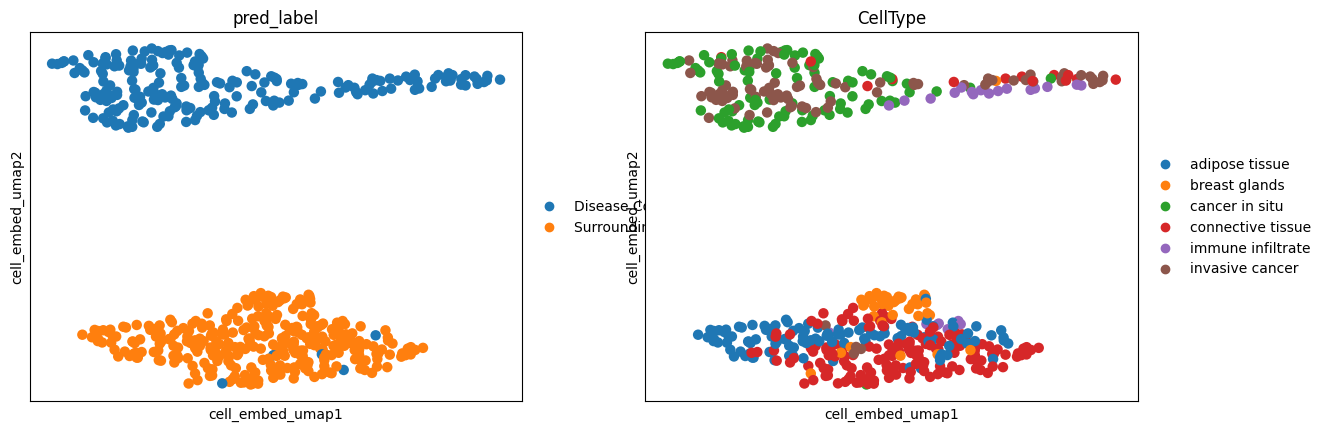

      DTS       F1  Balanced Accuracy  Accuracy  Precision    Recall  \
0  0.9183  0.90099           0.935611  0.924528    0.83871  0.973262   

   specificity  
0     0.897959  


In [83]:
adata_full = tools_v1.detect_core(adata_full,
               embed = 'cell_embed',
               section_ids = sections,
               core_types = ['cancer in situ', 'invasive cancer'],
               celltype_key='CellType',
               batch_key = 'batch',
               seed=seed,
               neighbors = 30,
               ifumap= True,
               threshold = 0.05,
               strategy = 'individual')
print(adata_full.uns['result'])

In [3]:
slice_name = 'H1'
post_adata_tar = sc.read(f'{dir_ana}ours_{slice_name}_tar.h5ad')

NameError: name 'dir_ana' is not defined

In [4]:
post_adata_tar.obsm['X_umap'] = post_adata_tar.obsm['spatial'].copy()
post_adata_tar.obsm['X_umap'][:, 1] *= -1
X_all = post_adata_tar.X.toarray()
ce_cell = post_adata_tar.obsm['pre_embed']
graph = post_adata_tar.obsp['graph'].toarray()
post_adata_tar.uns['gene_embed'] = tools_v1.gene_embed_weight(X_all, ce_cell, graph)
post_adata_tar.layers['dist'] = tools_v1.cell_to_gene_pdistance(ce_cell, post_adata_tar.uns['gene_embed'])
sig_list = tools_v1.select_sig_genes(adata=post_adata_tar,label_key='pred_label',topk=100)

In [5]:
len(sig_list["Disease Core"]["genes"][:100])

100

In [6]:
X_all = post_adata_tar.X.toarray()
ce_cell = post_adata_tar.obsm['pre_embed']
graph = post_adata_tar.obsp['graph'].toarray()
post_adata_tar.uns['gene_embed'] = tools_v1.gene_embed_weight(X_all, ce_cell, graph)
post_adata_tar.layers['dist'] = tools_v1.cell_to_gene_pdistance(ce_cell, post_adata_tar.uns['gene_embed'])
sig_list = tools_v1.select_sig_genes(adata=post_adata_tar,label_key='pred_label',topk=100)

In [7]:
sig_list['Disease Core']['genes']

['PPP6R2',
 'SEC16A',
 'SSRP1',
 'MMACHC',
 'ULK1',
 'GUSB',
 'PTTG1IP',
 'TBCB',
 'FOXM1',
 'CDC20',
 'DLG3',
 'SEPHS2',
 'DYNLL2',
 'DDX41',
 'MED22',
 'NUTF2',
 'TMEM203',
 'RAB3D',
 'SLC25A25',
 'DNMT3A',
 'IPO9',
 'C12orf49',
 'FAM193B',
 'DDX11',
 'HNRNPAB',
 'MCRS1',
 'PPP2R1A',
 'SLC6A9',
 'REXO4',
 'DHX8',
 'SMG9',
 'SERPINH1',
 'PARP12',
 'PSMD1',
 'PCSK1N',
 'ANAPC2',
 'SURF4',
 'FAM166A',
 'XBP1',
 'PPIL2',
 'GSK3A',
 'RNF126',
 'NR2F6',
 'IP6K2',
 'LSR',
 'TNPO2',
 'ICMT',
 'DBN1',
 'DOCK6',
 'MAST4',
 'LLGL2',
 'RAB11A',
 'AHSA1',
 'LPCAT1',
 'MLLT6',
 'RAB17',
 'KCTD2',
 'C16orf59',
 'NEUROD2',
 'CSNK1D',
 'SAT1',
 'POSTN',
 'AGAP3',
 'SPG7',
 'DDX39A',
 'PDRG1',
 'MMP15',
 'PCNX3',
 'SEPT9',
 'DEGS1',
 'KDM4A',
 'PHF12',
 'SPHK1',
 'TUBA1C',
 'GOT2',
 'SEMA4C',
 'MOGS',
 'UBE2L3',
 'PPP4C',
 'MIER2',
 'PLEKHG4B',
 'NOL10',
 'MAGED2',
 'KIF22',
 'SAPCD2',
 'SLC3A2',
 'PSMB5',
 'KIF1A',
 'GPRIN1',
 'AKT1',
 'GTF3C1',
 'WDR90',
 'BMF',
 'CHPF2',
 'SGSH',
 'SMARCC1',
 'ADAR

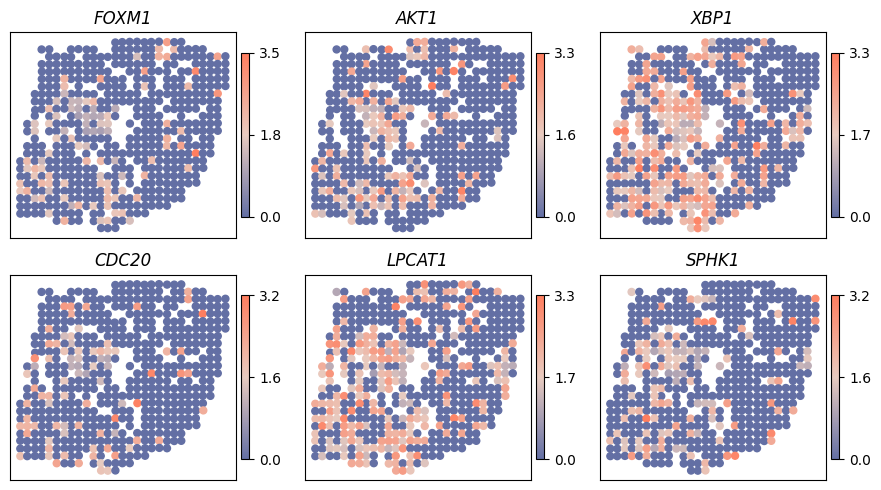

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 选取的基因列表
# gene_indices = [0,1,2,3,4,5,6,7]
# genes = [sig_list['Disease Core']['genes'][i] for i in gene_indices]
genes = [
    "FOXM1",
    "AKT1",
    "XBP1",
    "CDC20",
    "LPCAT1",
    "SPHK1",
]
# 布局参数
ncols = 3
nrows = int(np.ceil(len(genes) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5))
axes = axes.flatten()

# 获取 UMAP 坐标
umap_coords = post_adata_tar.obsm['X_umap']
x = umap_coords[:, 0]
y = umap_coords[:, 1]

for idx, gene in enumerate(genes):
    ax = axes[idx]
    
    # 获取基因表达值
    if gene in post_adata_tar.var_names:
        gene_idx = post_adata_tar.var_names.get_loc(gene)
        expr = post_adata_tar.X[:, gene_idx]
        if hasattr(expr, 'toarray'):  # 稀疏矩阵处理
            expr = expr.toarray().flatten()
    else:
        expr = np.zeros(len(x))
        print(f"Warning: {gene} not found in adata")
    
    from matplotlib.colors import LinearSegmentedColormap

    custom_cmap = LinearSegmentedColormap.from_list(
        "my_cmap",
        ["#636fa4", "#e8cbc0", "#ff7e5f"]
    )
    
    # 绘制散点图
    # viridis
    scm = ax.scatter(x, y, c=expr, cmap=custom_cmap, s=25, rasterized=True)
    
    # 标题设置（基因名，可调整 fontsize）
    # ax.set_title(gene, fontsize=12, fontweight='bold')
    ax.set_title(gene, fontsize=12, fontstyle='italic', fontweight='normal')
    
    # 隐藏坐标轴 title 和刻度
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 添加 colorbar
    # plt.colorbar(scm, ax=ax, shrink=0.8, pad=0.02)
    cbar = plt.colorbar(scm, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_ticks([expr.min(), (expr.min() + expr.max()) / 2, expr.max()])
    cbar.set_ticklabels([f'{expr.min():.1f}', 
                         f'{(expr.min() + expr.max()) / 2:.1f}', 
                         f'{expr.max():.1f}'])

# 隐藏多余的子图
for idx in range(len(genes), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(f"{dir_fig}{slice_name}_sgs.png", dpi=150, bbox_inches="tight")
plt.show()

In [155]:
disease_core_genes = set(sig_list['Disease Core']['genes'])

missing_genes = [g for g in genes if g not in disease_core_genes]

if len(missing_genes) == 0:
    print("All genes are in sig_list['Disease Core']['genes'].")
else:
    print(f"{len(missing_genes)} genes are missing:")
    print(missing_genes)

All genes are in sig_list['Disease Core']['genes'].


In [156]:
sig_list['Disease Core']['genes']

['PPP6R2',
 'SEC16A',
 'SSRP1',
 'MMACHC',
 'ULK1',
 'GUSB',
 'PTTG1IP',
 'TBCB',
 'FOXM1',
 'CDC20',
 'DLG3',
 'SEPHS2',
 'DYNLL2',
 'DDX41',
 'MED22',
 'NUTF2',
 'TMEM203',
 'RAB3D',
 'SLC25A25',
 'DNMT3A',
 'IPO9',
 'C12orf49',
 'FAM193B',
 'DDX11',
 'HNRNPAB',
 'MCRS1',
 'PPP2R1A',
 'SLC6A9',
 'REXO4',
 'DHX8',
 'SMG9',
 'SERPINH1',
 'PARP12',
 'PSMD1',
 'PCSK1N',
 'ANAPC2',
 'SURF4',
 'FAM166A',
 'XBP1',
 'PPIL2',
 'GSK3A',
 'RNF126',
 'NR2F6',
 'IP6K2',
 'LSR',
 'TNPO2',
 'ICMT',
 'DBN1',
 'DOCK6',
 'MAST4',
 'LLGL2',
 'RAB11A',
 'AHSA1',
 'LPCAT1',
 'MLLT6',
 'RAB17',
 'KCTD2',
 'C16orf59',
 'NEUROD2',
 'CSNK1D',
 'SAT1',
 'POSTN',
 'AGAP3',
 'SPG7',
 'DDX39A',
 'PDRG1',
 'MMP15',
 'PCNX3',
 'SEPT9',
 'DEGS1',
 'KDM4A',
 'PHF12',
 'SPHK1',
 'TUBA1C',
 'GOT2',
 'SEMA4C',
 'MOGS',
 'UBE2L3',
 'PPP4C',
 'MIER2',
 'PLEKHG4B',
 'NOL10',
 'MAGED2',
 'KIF22',
 'SAPCD2',
 'SLC3A2',
 'PSMB5',
 'KIF1A',
 'GPRIN1',
 'AKT1',
 'GTF3C1',
 'WDR90',
 'BMF',
 'CHPF2',
 'SGSH',
 'SMARCC1',
 'ADAR

## Go enrichment

In [15]:
slice_name = 'H1'
post_adata_tar = sc.read(f'{dir_ana}ours_{slice_name}_tar.h5ad')

In [16]:
post_adata_tar.obsm['X_umap'] = post_adata_tar.obsm['spatial'].copy()
post_adata_tar.obsm['X_umap'][:, 1] *= -1
X_all = post_adata_tar.X.toarray()
ce_cell = post_adata_tar.obsm['pre_embed']
graph = post_adata_tar.obsp['graph'].toarray()
post_adata_tar.uns['gene_embed'] = tools_v1.gene_embed_weight(X_all, ce_cell, graph)
post_adata_tar.layers['dist'] = tools_v1.cell_to_gene_pdistance(ce_cell, post_adata_tar.uns['gene_embed'])
sig_list = tools_v1.select_sig_genes(adata=post_adata_tar,label_key='pred_label',topk=100)

In [17]:
len(sig_list["Disease Core"]["genes"][:100])

100

In [18]:
sig_list["Disease Core"]["genes"][:100]

['PPP6R2',
 'SEC16A',
 'SSRP1',
 'MMACHC',
 'ULK1',
 'GUSB',
 'PTTG1IP',
 'TBCB',
 'FOXM1',
 'CDC20',
 'DLG3',
 'SEPHS2',
 'DYNLL2',
 'DDX41',
 'MED22',
 'NUTF2',
 'TMEM203',
 'RAB3D',
 'SLC25A25',
 'DNMT3A',
 'IPO9',
 'C12orf49',
 'FAM193B',
 'DDX11',
 'HNRNPAB',
 'MCRS1',
 'PPP2R1A',
 'SLC6A9',
 'REXO4',
 'DHX8',
 'SMG9',
 'SERPINH1',
 'PARP12',
 'PSMD1',
 'PCSK1N',
 'ANAPC2',
 'SURF4',
 'FAM166A',
 'XBP1',
 'PPIL2',
 'GSK3A',
 'RNF126',
 'NR2F6',
 'IP6K2',
 'LSR',
 'TNPO2',
 'ICMT',
 'DBN1',
 'DOCK6',
 'MAST4',
 'LLGL2',
 'RAB11A',
 'AHSA1',
 'LPCAT1',
 'MLLT6',
 'RAB17',
 'KCTD2',
 'C16orf59',
 'NEUROD2',
 'CSNK1D',
 'SAT1',
 'POSTN',
 'AGAP3',
 'SPG7',
 'DDX39A',
 'PDRG1',
 'MMP15',
 'PCNX3',
 'SEPT9',
 'DEGS1',
 'KDM4A',
 'PHF12',
 'SPHK1',
 'TUBA1C',
 'GOT2',
 'SEMA4C',
 'MOGS',
 'UBE2L3',
 'PPP4C',
 'MIER2',
 'PLEKHG4B',
 'NOL10',
 'MAGED2',
 'KIF22',
 'SAPCD2',
 'SLC3A2',
 'PSMB5',
 'KIF1A',
 'GPRIN1',
 'AKT1',
 'GTF3C1',
 'WDR90',
 'BMF',
 'CHPF2',
 'SGSH',
 'SMARCC1',
 'ADAR

In [22]:
import gseapy as gp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ── 0. 输入参数 ──────────────────────────────────────────────
MIN_COUNT = 5

main_gene_sets = [
    "GO_Biological_Process_2025",
    "MSigDB_Hallmark_2020",
    # "Reactome_2022",
    # "KEGG_2021_Human",
]

groups_to_enrich = [
    "Disease Core",
]

# ── 1. 工具函数 ──────────────────────────────────────────────
def extract_name(term):
    if "(" in term:
        return term[:term.rfind("(")].strip()
    return term


def wrap_label(text, max_len=45):
    words = text.split()
    lines, line = [], ""
    for w in words:
        if len(line) + len(w) + 1 <= max_len:
            line = (line + " " + w).strip()
        else:
            if line:
                lines.append(line)
            line = w
    if line:
        lines.append(line)
    return "\n".join(lines)


def run_enrichr_for_one_group(group_name, gene_list, min_count=5):
    gene_list = (
        pd.Series(gene_list)
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    if len(gene_list) == 0:
        return pd.DataFrame()

    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=main_gene_sets,
        organism="human",
        outdir=None,
        cutoff=0.05,
    )

    df = enr.results.copy()

    # 显著性筛选
    df = df[df["Adjusted P-value"] < 0.05].copy()
    if df.empty:
        return pd.DataFrame()

    # 统计量
    df["Group"] = group_name
    df["Count"] = df["Overlap"].apply(lambda x: int(x.split("/")[0]))
    df = df[df["Count"] >= min_count].copy()
    if df.empty:
        return pd.DataFrame()

    df["GeneRatio"] = df["Overlap"].apply(
        lambda x: int(x.split("/")[0]) / int(x.split("/")[1])
    )
    df["Term_Name"] = df["Term"].apply(extract_name)
    df["Term_Name_wrap"] = df["Term_Name"].apply(lambda x: wrap_label(x, max_len=32))
    df["neglog10_adjP"] = -np.log10(df["Adjusted P-value"].clip(lower=1e-300))

    return df


# ── 2. 分别计算两个 group 的富集结果（保留所有显著结果）──────────
enrich_all_list = []

for group_name in groups_to_enrich:
    gene_list = sig_list[group_name]["genes"]
    df_group = run_enrichr_for_one_group(
        group_name=group_name,
        gene_list=gene_list,
        min_count=MIN_COUNT,
    )
    enrich_all_list.append(df_group)

enrich_all_df = pd.concat(enrich_all_list, axis=0, ignore_index=True)

In [23]:
enrich_all_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Group,Count,GeneRatio,Term_Name,Term_Name_wrap,neglog10_adjP
0,GO_Biological_Process_2025,Establishment of Protein Localization to Organ...,6/90,0.000006,0.002853,0,0,15.057751,181.162775,IPO9;AKT1;NUTF2;PTTG1IP;TNPO2;RAB11A,Disease Core,6,0.066667,Establishment of Protein Localization to Organ...,Establishment of Protein\nLocalization to Orga...,2.544747
1,GO_Biological_Process_2025,Import Into Nucleus (GO:0051170),5/75,0.000037,0.006804,0,0,14.909774,152.166253,IPO9;AKT1;NUTF2;PTTG1IP;TNPO2,Disease Core,5,0.066667,Import Into Nucleus,Import Into Nucleus,2.167229
2,GO_Biological_Process_2025,Intracellular Protein Transport (GO:0006886),9/326,0.000038,0.006804,0,0,6.109717,62.235715,IPO9;SEC16A;SURF4;AKT1;ADAR;NUTF2;PTTG1IP;RAB1...,Disease Core,9,0.027607,Intracellular Protein Transport,Intracellular Protein Transport,2.167229
3,GO_Biological_Process_2025,Protein Localization to Nucleus (GO:0034504),6/127,0.000043,0.006804,0,0,10.433796,104.998603,IPO9;AKT1;ADAR;NUTF2;PTTG1IP;TNPO2,Disease Core,6,0.047244,Protein Localization to Nucleus,Protein Localization to Nucleus,2.167229
4,GO_Biological_Process_2025,Protein Import Into Nucleus (GO:0006606),5/80,0.000050,0.006907,0,0,13.912281,137.650438,IPO9;AKT1;NUTF2;PTTG1IP;TNPO2,Disease Core,5,0.062500,Protein Import Into Nucleus,Protein Import Into Nucleus,2.160715
5,GO_Biological_Process_2025,Positive Regulation of Cellular Component Orga...,5/111,0.000238,0.027543,0,0,9.828203,81.993734,CDC20;NEUROD2;SURF4;BMF;ANAPC2,Disease Core,5,0.045045,Positive Regulation of Cellular Component Orga...,Positive Regulation of Cellular\nComponent Org...,1.559993
6,GO_Biological_Process_2025,Regulation of Protein Ubiquitination (GO:0031396),5/113,0.000259,0.027543,0,0,9.645224,79.666088,GSK3A;SPHK1;AKT1;PTTG1IP;UBE2L3,Disease Core,5,0.044248,Regulation of Protein Ubiquitination,Regulation of Protein\nUbiquitination,1.559993
7,GO_Biological_Process_2025,Proteasome-Mediated Ubiquitin-Dependent Protei...,8/340,0.000308,0.029468,0,0,5.125196,41.446046,CDC20;RNF126;GSK3A;PSMB5;PSMD1;KCTD2;AGAP3;ANAPC2,Disease Core,8,0.023529,Proteasome-Mediated Ubiquitin-Dependent Protei...,Proteasome-Mediated\nUbiquitin-Dependent Prote...,1.530654
8,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,9/455,0.000461,0.036774,0,0,4.313951,33.143719,RNF126;XBP1;GSK3A;PSMB5;PSMD1;KCTD2;AGAP3;MMAC...,Disease Core,9,0.019780,Ubiquitin-Dependent Protein Catabolic Process,Ubiquitin-Dependent Protein\nCatabolic Process,1.434464
9,MSigDB_Hallmark_2020,G2-M Checkpoint,5/200,0.003324,0.035454,0,0,5.318489,30.350700,CDC20;SMARCC1;DDX39A;KIF22;TNPO2,Disease Core,5,0.025000,G2-M Checkpoint,G2-M Checkpoint,1.450334


In [159]:
plot_pathways_main = [
    # Hallmark: proliferative / oncogenic tumor-core programs
    "E2F Targets",
    "G2-M Checkpoint",
    "Myc Targets V1",

    # GO BP: protein turnover / proteostasis / nuclear transport
    "Proteasome-Mediated Ubiquitin-Dependent Protein Catabolic Process (GO:0043161)",
    "Regulation of Protein Ubiquitination (GO:0031396)",
    "Protein Import Into Nucleus (GO:0006606)"
]

In [160]:
# ── 从 enrich_all_df 中手动筛选指定通路 ─────────────────────────

hallmark_terms = [
    "E2F Targets",
    "G2-M Checkpoint",
    "Myc Targets V1",   
]

gobp_terms = [
    "Proteasome-Mediated Ubiquitin-Dependent Protein Catabolic Process (GO:0043161)",
    "Regulation of Protein Ubiquitination (GO:0031396)",
    "Protein Import Into Nucleus (GO:0006606)"
]

# 指定展示顺序
select_order = (
    [("MSigDB_Hallmark_2020", t) for t in hallmark_terms] +
    [("GO_Biological_Process_2025", t) for t in gobp_terms]
)

# 按指定 group 和 term 精确筛选
select_rows = []

for group_name, term in select_order:
    sub = enrich_all_df[
        (enrich_all_df["Gene_set"] == group_name) &
        (enrich_all_df["Term"] == term)
    ].copy()

    if sub.empty:
        print(f"Warning: not found -> [{group_name}] {term}")
    else:
        select_rows.append(sub.iloc[0])

enrich_select_df = pd.DataFrame(select_rows).reset_index(drop=True)

enrich_select_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Group,Count,GeneRatio,Term_Name,Term_Name_wrap,neglog10_adjP
0,MSigDB_Hallmark_2020,E2F Targets,5/200,0.003324,0.035454,0,0,5.318489,30.350700,CDC20;DDX39A;WDR90;KIF22;SSRP1,Disease Core,5,0.025000,E2F Targets,E2F Targets,1.450334
1,MSigDB_Hallmark_2020,G2-M Checkpoint,5/200,0.003324,0.035454,0,0,5.318489,30.350700,CDC20;SMARCC1;DDX39A;KIF22;TNPO2,Disease Core,5,0.025000,G2-M Checkpoint,G2-M Checkpoint,1.450334
2,MSigDB_Hallmark_2020,Myc Targets V1,5/200,0.003324,0.035454,0,0,5.318489,30.350700,CDC20;SMARCC1;GOT2;PSMD1;UBE2L3,Disease Core,5,0.025000,Myc Targets V1,Myc Targets V1,1.450334
3,GO_Biological_Process_2025,Proteasome-Mediated Ubiquitin-Dependent Protei...,8/340,0.000308,0.029468,0,0,5.125196,41.446046,CDC20;RNF126;GSK3A;PSMB5;PSMD1;KCTD2;AGAP3;ANAPC2,Disease Core,8,0.023529,Proteasome-Mediated Ubiquitin-Dependent Protei...,Proteasome-Mediated\nUbiquitin-Dependent Prote...,1.530654
4,GO_Biological_Process_2025,Regulation of Protein Ubiquitination (GO:0031396),5/113,0.000259,0.027543,0,0,9.645224,79.666088,GSK3A;SPHK1;AKT1;PTTG1IP;UBE2L3,Disease Core,5,0.044248,Regulation of Protein Ubiquitination,Regulation of Protein\nUbiquitination,1.559993
5,GO_Biological_Process_2025,Protein Import Into Nucleus (GO:0006606),5/80,0.000050,0.006907,0,0,13.912281,137.650438,IPO9;AKT1;NUTF2;PTTG1IP;TNPO2,Disease Core,5,0.062500,Protein Import Into Nucleus,Protein Import Into Nucleus,2.160715


In [24]:
enrich_select_df = enrich_all_df.copy()

In [25]:
terms = enrich_select_df.loc[
    enrich_select_df['Gene_set'] == 'GO_Biological_Process_2025',
    'Term'
].tolist()

In [26]:
terms

['Establishment of Protein Localization to Organelle (GO:0072594)',
 'Import Into Nucleus (GO:0051170)',
 'Intracellular Protein Transport (GO:0006886)',
 'Protein Localization to Nucleus (GO:0034504)',
 'Protein Import Into Nucleus (GO:0006606)',
 'Positive Regulation of Cellular Component Organization (GO:0051130)',
 'Regulation of Protein Ubiquitination (GO:0031396)',
 'Proteasome-Mediated Ubiquitin-Dependent Protein Catabolic Process (GO:0043161)',
 'Ubiquitin-Dependent Protein Catabolic Process (GO:0006511)']

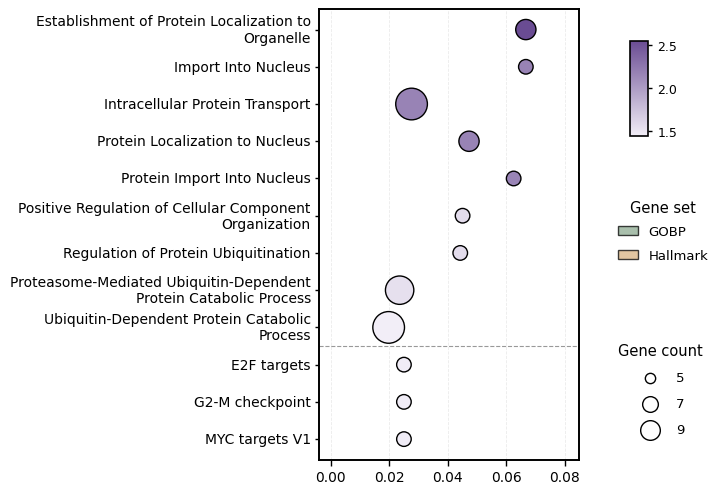

In [27]:
import os
import textwrap

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


# ============================================================
# 0. 标签换行函数
# ============================================================
def wrap_label(text, max_len=42):
    """
    将较长的 pathway 名称自动换行。
    """
    return "\n".join(
        textwrap.wrap(
            str(text),
            width=max_len,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )


def parse_gene_ratio(x):
    """
    将 GeneRatio 转成数值。

    支持：
    1) 数值型，例如 0.05
    2) 字符串小数，例如 "0.05"
    3) 分数字符串，例如 "5/100"
    """
    if pd.isna(x):
        return np.nan

    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    x = str(x).strip()

    if "/" in x:
        num, den = x.split("/", 1)
        try:
            return float(num) / float(den)
        except Exception:
            return np.nan

    try:
        return float(x)
    except Exception:
        return np.nan


# ============================================================
# 1. 手动指定通路顺序
#    GOBP 在上
#    Hallmark 在下
# ============================================================

# terms 为之前提取的 GO_Biological_Process_2025 Term
gobp_terms = terms

hallmark_terms = [
    "E2F Targets",
    "G2-M Checkpoint",
    "Myc Targets V1",
]

plot_order = (
    [("GO_Biological_Process_2025", term) for term in gobp_terms]
    +
    [("MSigDB_Hallmark_2020", term) for term in hallmark_terms]
)


# ============================================================
# 2. Pathway 展示名称
# ============================================================
pathway_name_map = {

    # -------------------------
    # GO Biological Process
    # -------------------------
    "Establishment of Protein Localization to Organelle (GO:0072594)":
        "Establishment of Protein Localization to Organelle",

    "Import Into Nucleus (GO:0051170)":
        "Import Into Nucleus",

    "Intracellular Protein Transport (GO:0006886)":
        "Intracellular Protein Transport",

    "Protein Localization to Nucleus (GO:0034504)":
        "Protein Localization to Nucleus",

    "Protein Import Into Nucleus (GO:0006606)":
        "Protein Import Into Nucleus",

    "Positive Regulation of Cellular Component Organization (GO:0051130)":
        "Positive Regulation of Cellular Component Organization",

    "Regulation of Protein Ubiquitination (GO:0031396)":
        "Regulation of Protein Ubiquitination",

    "Proteasome-Mediated Ubiquitin-Dependent Protein Catabolic Process (GO:0043161)":
        "Proteasome-Mediated Ubiquitin-Dependent Protein Catabolic Process",

    "Ubiquitin-Dependent Protein Catabolic Process (GO:0006511)":
        "Ubiquitin-Dependent Protein Catabolic Process",

    # -------------------------
    # Hallmark
    # -------------------------
    "E2F Targets":
        "E2F targets",

    "G2-M Checkpoint":
        "G2-M checkpoint",

    "Myc Targets V1":
        "MYC targets V1",
}


# ============================================================
# 3. Gene set 颜色
# ============================================================
gene_set_colors = {
    "GO_Biological_Process_2025": "#8DAA91",
    "MSigDB_Hallmark_2020": "#D9B382",
}

gene_set_labels = {
    "GO_Biological_Process_2025": "GOBP",
    "MSigDB_Hallmark_2020": "Hallmark",
}


# ============================================================
# 4. 检查所需列
# ============================================================
required_columns = {
    "Gene_set",
    "Term",
    "GeneRatio",
    "Count",
    "Adjusted P-value",
}

missing_columns = required_columns.difference(
    enrich_select_df.columns
)

if missing_columns:
    raise KeyError(
        "The following required columns are missing from "
        f"enrich_select_df: {sorted(missing_columns)}"
    )


# ============================================================
# 5. 按指定顺序提取 pathway
# ============================================================
plot_rows = []

for gene_set_name, term_name in plot_order:

    sub = enrich_select_df.loc[
        (enrich_select_df["Gene_set"] == gene_set_name)
        &
        (enrich_select_df["Term"] == term_name)
    ].copy()

    if sub.empty:

        print(
            f"Warning: not found -> "
            f"Gene_set = [{gene_set_name}], "
            f"Term = [{term_name}]"
        )

    else:

        # 如果同一个 Gene_set + Term 有多条记录，
        # 保留 adjusted P-value 最小的一条
        sub["_adjp_numeric"] = pd.to_numeric(
            sub["Adjusted P-value"],
            errors="coerce",
        )

        sub = sub.sort_values(
            "_adjp_numeric",
            ascending=True,
            na_position="last",
        )

        plot_rows.append(
            sub.iloc[0]
        )


plot_df = pd.DataFrame(
    plot_rows
).reset_index(drop=True)


if plot_df.empty:
    raise ValueError(
        "No selected pathways were found. "
        "Please check the Gene_set and Term names."
    )


if "_adjp_numeric" in plot_df.columns:
    plot_df = plot_df.drop(
        columns=["_adjp_numeric"]
    )


# ============================================================
# 6. 组织绘图数据
# ============================================================

# 增加相邻 pathway 的纵向距离
# 避免长 GO term 标签互相覆盖
y_step = 1.15

plot_df["y"] = (
    np.arange(
        len(plot_df) - 1,
        -1,
        -1
    )
    * y_step
    + 1
)


plot_df["x"] = plot_df["GeneRatio"].apply(
    parse_gene_ratio
)


plot_df["Count"] = pd.to_numeric(
    plot_df["Count"],
    errors="coerce",
)


if plot_df["x"].isna().any():

    bad_rows = plot_df.loc[
        plot_df["x"].isna(),
        [
            "Gene_set",
            "Term",
            "GeneRatio",
        ]
    ]

    raise ValueError(
        "GeneRatio contains non-numeric or missing values:\n"
        f"{bad_rows}"
    )


if plot_df["Count"].isna().any():

    bad_rows = plot_df.loc[
        plot_df["Count"].isna(),
        [
            "Gene_set",
            "Term",
            "Count",
        ]
    ]

    raise ValueError(
        "Count contains non-numeric or missing values:\n"
        f"{bad_rows}"
    )


# ============================================================
# 7. 生成展示名称
# ============================================================
plot_df["DisplayTerm"] = (
    plot_df["Term"]
    .map(pathway_name_map)
)

plot_df["DisplayTerm"] = (
    plot_df["DisplayTerm"]
    .fillna(plot_df["Term"])
)


plot_df["Label"] = (
    plot_df["DisplayTerm"]
    .apply(
        lambda x: wrap_label(
            x,
            max_len=42,
        )
    )
)


# ============================================================
# 8. 计算 -log10(adjusted P)
# ============================================================
if "neglog10_adjP" not in plot_df.columns:

    adjusted_p = pd.to_numeric(
        plot_df["Adjusted P-value"],
        errors="coerce",
    )

    if adjusted_p.isna().any():

        bad_rows = plot_df.loc[
            adjusted_p.isna(),
            [
                "Gene_set",
                "Term",
                "Adjusted P-value",
            ]
        ]

        raise ValueError(
            "Adjusted P-value contains non-numeric "
            "or missing values:\n"
            f"{bad_rows}"
        )

    plot_df["neglog10_adjP"] = (
        -np.log10(
            adjusted_p.clip(
                lower=1e-300
            )
        )
    )

else:

    plot_df["neglog10_adjP"] = pd.to_numeric(
        plot_df["neglog10_adjP"],
        errors="coerce",
    )

    if plot_df["neglog10_adjP"].isna().any():

        bad_rows = plot_df.loc[
            plot_df["neglog10_adjP"].isna(),
            [
                "Gene_set",
                "Term",
                "neglog10_adjP",
            ]
        ]

        raise ValueError(
            "neglog10_adjP contains non-numeric "
            "or missing values:\n"
            f"{bad_rows}"
        )


# ============================================================
# 9. 气泡大小映射
# ============================================================
count_min = plot_df["Count"].min()
count_max = plot_df["Count"].max()


def scale_size(
    x,
    min_size=110,
    max_size=520
):
    """
    主图气泡大小。
    """

    if count_min == count_max:
        return (
            min_size + max_size
        ) / 2

    return (
        min_size
        +
        (x - count_min)
        / (count_max - count_min)
        * (max_size - min_size)
    )


plot_df["Size"] = plot_df["Count"].apply(
    scale_size
)


# ============================================================
# 10. 创建画布
# ============================================================

# 加高画布，避免大量 pathway 纵向拥挤
fig, ax = plt.subplots(
    figsize=(8.4, 5.3)
)

# 左边给 pathway label 留空间
# 右边给 colorbar 和 legend 留空间
plt.subplots_adjust(
    left=0.42,
    right=0.73,
    bottom=0.11,
    top=0.96,
)


# ============================================================
# 11. 设置颜色映射
# ============================================================
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "single_purple_gradient",
    [
        "#F2EEF7",
        "#6A4C93",
    ]
)


color_min = plot_df[
    "neglog10_adjP"
].min()

color_max = plot_df[
    "neglog10_adjP"
].max()


if np.isclose(
    color_min,
    color_max
):
    color_min -= 0.5
    color_max += 0.5


norm = mpl.colors.Normalize(
    vmin=color_min,
    vmax=color_max,
)


# ============================================================
# 12. 统计不同 gene set 数量
# ============================================================
n_gobp_found = (
    plot_df["Gene_set"]
    ==
    "GO_Biological_Process_2025"
).sum()


n_hallmark_found = (
    plot_df["Gene_set"]
    ==
    "MSigDB_Hallmark_2020"
).sum()


# ============================================================
# 13. 绘制气泡图
# ============================================================
sc = ax.scatter(
    plot_df["x"],
    plot_df["y"],

    s=plot_df["Size"],

    c=plot_df[
        "neglog10_adjP"
    ],

    cmap=cmap,
    norm=norm,

    edgecolor="black",
    linewidth=1.0,

    zorder=3,
)


# ============================================================
# 14. 设置 y 轴
# ============================================================
ax.set_yticks(
    plot_df["y"]
)

ax.set_yticklabels(
    plot_df["Label"],
    fontsize=10,
    rotation=0,
    ha="right",
    va="center",
)


ax.tick_params(
    axis="y",
    which="major",

    length=3,
    width=1.0,

    direction="out",

    # label 与 y-axis 之间稍微留一点距离
    pad=3,
)


# y 轴上下留白
ax.set_ylim(
    plot_df["y"].min() - 0.55 * y_step,
    plot_df["y"].max() + 0.55 * y_step,
)


# ============================================================
# 15. 设置 x 轴
# ============================================================
xmax_data = plot_df["x"].max()


xtick_max = (
    np.ceil(
        xmax_data / 0.01
    )
    * 0.01
)


if xtick_max <= 0:
    xtick_max = 0.01


x_right_margin = 0.015
x_left_margin = 0.004


xmax = (
    xtick_max
    +
    x_right_margin
)


ax.set_xlim(
    -x_left_margin,
    xmax,
)


xticks = np.arange(
    0,
    xtick_max + 0.02,
    0.02,
)


ax.set_xticks(
    xticks
)

ax.set_xticklabels(
    [
        f"{x:.2f}"
        for x in xticks
    ],
    fontsize=10,
)


ax.tick_params(
    axis="x",
    which="major",

    length=4,
    width=1.0,

    direction="out",
)


# 如需要 x-axis title，可取消注释
# ax.set_xlabel(
#     "GeneRatio",
#     fontsize=11
# )


# ============================================================
# 16. GOBP / Hallmark 分界线
# ============================================================
if (
    n_gobp_found > 0
    and
    n_hallmark_found > 0
):

    gobp_y_min = (
        plot_df.loc[
            plot_df["Gene_set"]
            ==
            "GO_Biological_Process_2025",
            "y",
        ]
        .min()
    )


    hallmark_y_max = (
        plot_df.loc[
            plot_df["Gene_set"]
            ==
            "MSigDB_Hallmark_2020",
            "y",
        ]
        .max()
    )


    boundary_y = (
        gobp_y_min
        +
        hallmark_y_max
    ) / 2


    ax.axhline(
        y=boundary_y,

        color="gray",

        linestyle="--",

        linewidth=0.8,

        alpha=0.8,

        zorder=2,
    )


# ============================================================
# 17. 添加竖向参考线
# ============================================================
ax.grid(
    axis="x",

    linestyle="--",

    linewidth=0.6,

    alpha=0.25,

    zorder=1,
)


# ============================================================
# 18. 主图边框
# ============================================================
for spine in ax.spines.values():

    spine.set_visible(True)

    spine.set_linewidth(
        1.4
    )

    spine.set_color(
        "black"
    )


# ============================================================
# 19. Colorbar
# ============================================================

# 单独放置在右上角
cax = fig.add_axes(
    [
        0.79,   # left
        0.72,   # bottom
        0.022,  # width
        0.18,   # height
    ]
)

cbar = plt.colorbar(
    sc,
    cax=cax,
)

cbar.ax.tick_params(
    labelsize=9,
    width=1.0,
    length=3,
)

cbar.outline.set_visible(True)
cbar.outline.set_linewidth(1.2)
cbar.outline.set_edgecolor("black")


# 如果需要 colorbar title
# cbar.set_label(
#     r"$-\log_{10}$(adjusted P)",
#     fontsize=9
# )


# ============================================================
# 20. Gene set legend
# ============================================================
gene_set_handles = [

    Patch(
        facecolor=gene_set_colors[
            "GO_Biological_Process_2025"
        ],

        edgecolor="black",

        label="GOBP",

        alpha=0.75,
    ),

    Patch(
        facecolor=gene_set_colors[
            "MSigDB_Hallmark_2020"
        ],

        edgecolor="black",

        label="Hallmark",

        alpha=0.75,
    ),
]


gene_set_legend = fig.legend(
    handles=gene_set_handles,
    title="Gene set",
    frameon=False,

    fontsize=9.5,
    title_fontsize=10.5,

    loc="upper left",
    bbox_to_anchor=(0.77, 0.61),

    borderaxespad=0.0,
    labelspacing=0.8,
    handlelength=1.5,
    handletextpad=0.8,
)


# ============================================================
# 21. Gene count legend
# ============================================================

legend_counts = [5, 7, 9]

# legend_counts = sorted(
#     plot_df[
#         "Count"
#     ]
#     .dropna()
#     .unique()
# )


# # 如果 count 太多，只展示 min / middle / max
# if len(legend_counts) > 3:

#     legend_counts = [

#         legend_counts[0],

#         legend_counts[
#             len(legend_counts) // 2
#         ],

#         legend_counts[-1],
#     ]


def scale_legend_size(
    x,
    min_size=55,
    max_size=200,
):
    """
    Legend 中气泡稍微缩小。
    """

    if count_min == count_max:

        return (
            min_size
            +
            max_size
        ) / 2

    return (
        min_size
        +
        (x - count_min)
        /
        (count_max - count_min)
        *
        (max_size - min_size)
    )


handles_size = [

    ax.scatter(
        [],
        [],

        s=scale_legend_size(
            count
        ),

        facecolor="white",

        edgecolor="black",

        linewidth=1.0,
    )

    for count
    in legend_counts
]


labels_size = [

    str(int(count))
    if float(count).is_integer()
    else str(count)

    for count
    in legend_counts
]


size_legend = fig.legend(
    handles_size,
    labels_size,

    title="Gene count",
    scatterpoints=1,
    frameon=False,

    fontsize=9.5,
    title_fontsize=10.5,

    loc="upper left",
    bbox_to_anchor=(0.77, 0.34),

    borderaxespad=0.0,
    labelspacing=1.0,
    handletextpad=1.0,
)


# ============================================================
# 22. 保存
# ============================================================
os.makedirs(
    dir_fig,
    exist_ok=True
)


save_path = os.path.join(
    dir_fig,
    f"{slice_name}_gobp_hallmark_bubble.png",
)


plt.savefig(
    save_path,

    dpi=300,

    bbox_inches="tight",
)


plt.show()